Running Value Iteration...


  1%|          | 8/1000 [00:00<00:00, 11397.57it/s]


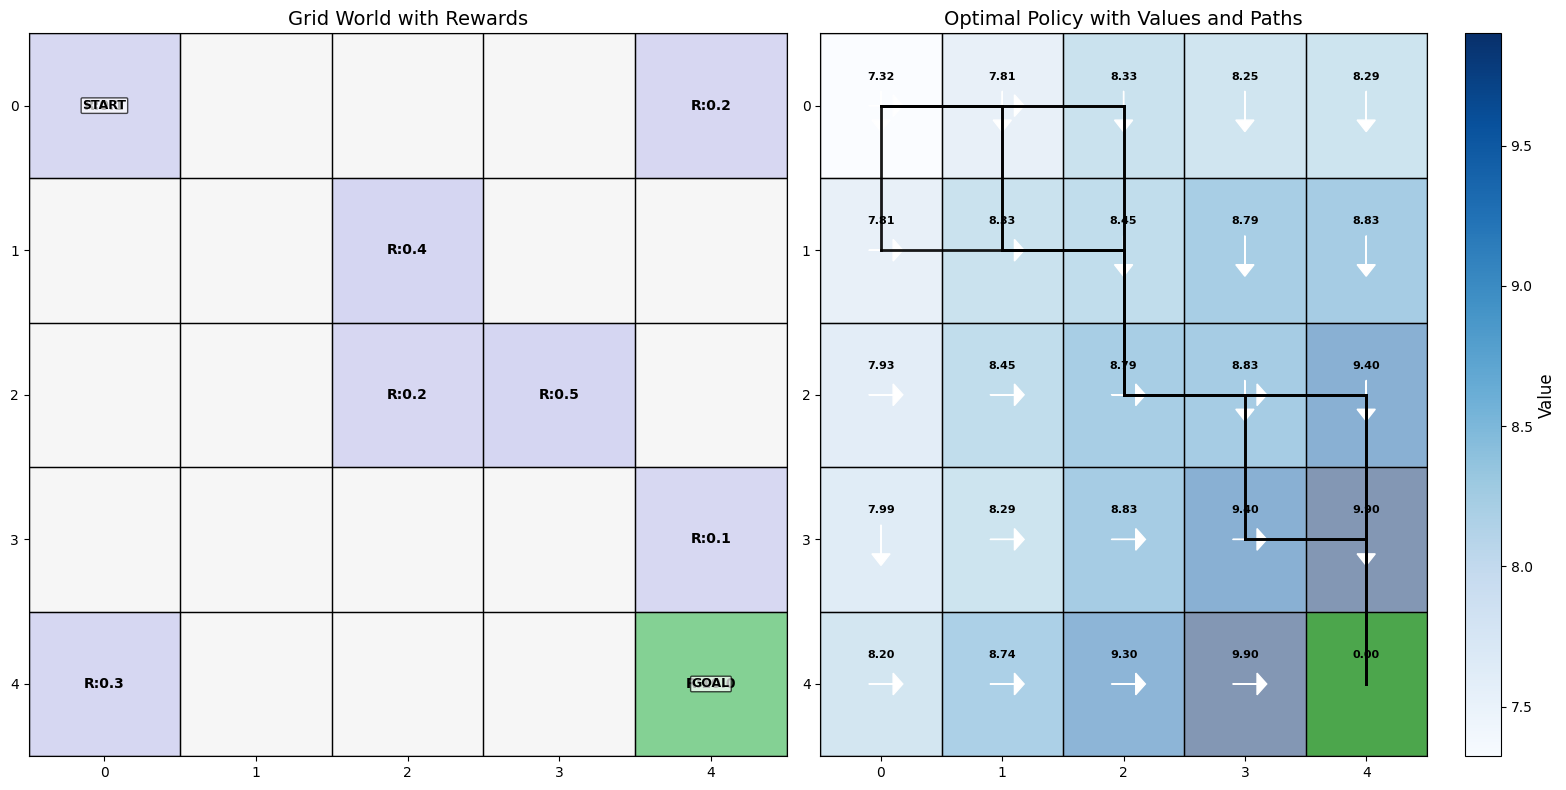

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from tqdm import tqdm

# Environment configuration
N = 5
ACTIONS = ['L', 'R', 'U', 'D', 'S']
ACTION_VECTORS = {'L': (0, -1), 'R': (0, 1), 'U': (-1, 0), 'D': (1, 0), 'S': (0, 0)}
ACTION_SYMBOLS = {'L': '←', 'R': '→', 'U': '↑', 'D': '↓', 'S': '•'}

def all_states(N):
    return [(r, c) for r in range(N) for c in range(N)]

def is_terminal(s, N):
    return s == (N-1, N-1)

def get_rewards(N):
    rewards = {}
    rewards[(N-1, N-1)] = 10.0
    rewards[(N-2, N-1)] = 0.1
    rewards[(N//2, N//2)] = 0.2
    rewards[(0, 0)] = 0.1
    rewards[(0, N-1)] = 0.2
    rewards[(N-1, 0)] = 0.3
    rewards[(N//2-1, N//2)] = 0.4
    rewards[(N//2, N//2+1)] = 0.5
    return rewards

def next_state_reward(s, a, N, rewards, penalty=-0.1):
    r, c = s
    if is_terminal(s, N):
        return s, 0.0, True
    
    dr, dc = ACTION_VECTORS[a]
    nr, nc = r + dr, c + dc
    if nr < 0 or nr >= N or nc < 0 or nc >= N:
        nr, nc = r, c
    
    ns = (nr, nc)
    reward = penalty
    if ns in rewards:
        reward += rewards[ns]
    
    done = ns == (N-1, N-1)
    return ns, reward, done

def value_iteration(N, rewards, gamma=0.95, theta=1e-6, max_iterations=1000):
    V = {s: 0.0 for s in all_states(N)}
    policy = {}
    iterations = 0
    bellman_errors = []
    
    print("Running Value Iteration...")
    for iterations in tqdm(range(1, max_iterations+1)):
        delta = 0
        for s in all_states(N):
            if is_terminal(s, N): continue
            
            v = V[s]
            best_q = float('-inf')
            for a in ACTIONS:
                ns, r, done = next_state_reward(s, a, N, rewards)
                q_sa = r + (0 if done else gamma * V[ns])
                best_q = max(best_q, q_sa)
            
            delta = max(delta, abs(v - best_q))
            V[s] = best_q
        
        bellman_errors.append(delta)
        if delta < theta:
            break
    
    # Extract policy with tied optimal actions
    for s in all_states(N):
        if is_terminal(s, N):
            policy[s] = None
            continue
        
        action_values = {}
        for a in ACTIONS:
            ns, r, done = next_state_reward(s, a, N, rewards)
            q_sa = r + (0 if done else gamma * V[ns])
            action_values[a] = q_sa
        
        max_value = max(action_values.values())
        # Find all actions within epsilon of max value (ties)
        epsilon = 1e-6
        optimal_actions = [a for a, v in action_values.items() if abs(v - max_value) < epsilon]
        policy[s] = optimal_actions
    
    return V, policy, iterations, bellman_errors

def find_optimal_paths(N, policy, start=(0, 0), max_steps=100):
    """Find all optimal paths based on policy with possible ties"""
    def dfs(current, path, paths):
        if is_terminal(current, N) or len(path) > max_steps:
            paths.append(path.copy())
            return
        
        if policy.get(current) is None:
            paths.append(path.copy())
            return
        
        for action in policy[current]:
            next_state, _, _ = next_state_reward(current, action, N, rewards)
            if next_state not in path:  # Avoid cycles
                path.append(next_state)
                dfs(next_state, path, paths)
                path.pop()  # Backtrack
    
    all_paths = []
    dfs(start, [start], all_paths)
    return all_paths

def plot_grid_world(N, rewards, V, policy):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plot 1: Initial grid with just rewards
    ax = axes[0]
    for i in range(N+1):
        ax.axhline(i, color='black', lw=1)
        ax.axvline(i, color='black', lw=1)
    
    # Color cells based on rewards with more neutral colors
    for r in range(N):
        for c in range(N):
            s = (r, c)
            # Cell color based on reward
            if is_terminal(s, N):
                color = (0.2, 0.7, 0.3)  # Softer green
                alpha = 0.6
            elif s in rewards:
                intensity = min(1.0, rewards[s] / 10.0)
                # Use blue gradient (more neutral than red-yellow)
                color = (0.7 - intensity*0.5, 0.7 - intensity*0.3, 0.9)
                alpha = 0.5
            else:
                color = 'lightgray'
                alpha = 0.2
            
            ax.add_patch(Rectangle((c, N-r-1), 1, 1, facecolor=color, alpha=alpha, edgecolor='gray'))
    
    # Add reward labels
    for (r, c), value in rewards.items():
        ax.text(c+0.5, N-r-0.5, f"R:{value}", ha='center', va='center', 
               fontsize=10, color='black', fontweight='bold')
    
    # Mark start and terminal
    ax.text(0.5, N-0.5, "START", ha='center', va='center', 
           fontsize=9, color='black', fontweight='bold',
           bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.1'))
    
    ax.text(N-1+0.5, N-(N-1)-0.5, "GOAL", ha='center', va='center', 
           fontsize=9, color='black', fontweight='bold',
           bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.1'))
    
    ax.set_xlim(0, N)
    ax.set_ylim(0, N)
    ax.set_xticks(np.arange(0.5, N, 1))
    ax.set_yticks(np.arange(0.5, N, 1))
    ax.set_xticklabels(range(N))
    ax.set_yticklabels(range(N-1, -1, -1))
    ax.set_title('Grid World with Rewards', fontsize=14)
    
    # Plot 2: Optimal policy with values and paths
    ax = axes[1]
    
    # Create a colormap for value function - light to deep blue
    cmap = plt.cm.Blues
    
    # Normalize values (excluding terminal for better scaling)
    all_v = [V[s] for s in all_states(N) if not is_terminal(s, N)]
    vmin, vmax = min(all_v), max(all_v)
    norm = plt.Normalize(vmin, vmax)
    
    for i in range(N+1):
        ax.axhline(i, color='black', lw=1)
        ax.axvline(i, color='black', lw=1)
    
    # Color cells based on value function
    for r in range(N):
        for c in range(N):
            s = (r, c)
            # Cell color based on value
            if is_terminal(s, N):
                color = 'green'
                alpha = 0.7
            else:
                color = cmap(norm(V[s]))
                alpha = 0.5
            
            ax.add_patch(Rectangle((c, N-r-1), 1, 1, facecolor=color, alpha=alpha, edgecolor='gray'))
            
            # Show value
            ax.text(c+0.5, N-r-0.3, f"{V[s]:.2f}", ha='center', va='center', 
                   fontsize=8, color='black', fontweight='bold')
    
    # Draw policy arrows - smaller and white
    for (r, c) in all_states(N):
        if policy.get((r, c)) is None:
            continue
        
        for a in policy[(r, c)]:
            if a == 'L':
                ax.arrow(c+0.6, N-r-0.5, -0.2, 0, head_width=0.15, head_length=0.08, fc='white', ec='white')
            elif a == 'R':
                ax.arrow(c+0.4, N-r-0.5, 0.2, 0, head_width=0.15, head_length=0.08, fc='white', ec='white')
            elif a == 'U':
                ax.arrow(c+0.5, N-r-0.6, 0, 0.2, head_width=0.15, head_length=0.08, fc='white', ec='white')
            elif a == 'D':
                ax.arrow(c+0.5, N-r-0.4, 0, -0.2, head_width=0.15, head_length=0.08, fc='white', ec='white')
            elif a == 'S':
                ax.add_patch(plt.Circle((c+0.5, N-r-0.5), 0.08, fc='white'))
    
    # Find and draw optimal paths - black for better contrast
    optimal_paths = find_optimal_paths(N, policy)
    
    # Draw each path with black
    for i, path in enumerate(optimal_paths[:5]):  # Limit to 5 paths for clarity
        # Draw path
        for j in range(len(path) - 1):
            r1, c1 = path[j]
            r2, c2 = path[j+1]
            ax.plot([c1+0.5, c2+0.5], [N-r1-0.5, N-r2-0.5], 
                   color='black', lw=2, alpha=0.9, linestyle='-')
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Value', fontsize=12)
    
    ax.set_xlim(0, N)
    ax.set_ylim(0, N)
    ax.set_xticks(np.arange(0.5, N, 1))
    ax.set_yticks(np.arange(0.5, N, 1))
    ax.set_xticklabels(range(N))
    ax.set_yticklabels(range(N-1, -1, -1))
    ax.set_title('Optimal Policy with Values and Paths', fontsize=14)
    
    plt.tight_layout()
    plt.show()
    return fig

# Run value iteration
rewards = get_rewards(N)
V, policy, iterations, bellman_errors = value_iteration(N, rewards)

# Plot results
fig = plot_grid_world(N, rewards, V, policy)

In [15]:
import numpy as np
import random
import time
import pandas as pd
from tabulate import tabulate
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# Common hyperparameters
COMMON_PARAMS = {
    'gamma': 0.95,
    'theta': 1e-6,
    'penalty': -0.1
}

# Algorithm-specific hyperparameters
ALGORITHM_PARAMS = {
    'VI': {
        'max_iterations': 1000,
    },
    'PI': {
        'max_iterations': 1000,
        'max_eval_iterations': 100,
    },
    'Q': {
        'alpha': 0.1,
        'epsilon_start': 1.0,
        'episodes': 5000,
        'step_limit': 50,
        'convergence_window': 500,
        'convergence_threshold': 0.0001,
    },
    'SARSA': {
        'alpha': 0.1,
        'epsilon_start': 1.0,
        'episodes': 5000,
        'step_limit': 50,
        'convergence_window': 500,
        'convergence_threshold': 0.0001,
    },
    'MC': {
        'alpha': 0.1,
        'epsilon_start': 1.0,
        'episodes': 5000,
        'step_limit': 50,
        'convergence_window': 500,
        'convergence_threshold': 0.0001,
        'exploration_bonus': 0.1,
    },
    'REINFORCE': {
        'lr_start': 0.01,  # Lower learning rate
        'entropy_weight': 0.05,
        'hidden_size': 128,  # Increased hidden size
        'episodes': 50_000,
        'step_limit': 50,
        'convergence_window': 500,
        'convergence_threshold': 0.0001,
        'grad_clip': 2.0,
        'batch_size': 128  # Added batch size
    }
}

def run_algorithms(N=5):
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    
    rewards = get_rewards(N)
    
    results = {
        'Method': [],
        'MSE Value': [],
        'Policy Match': [],
        'Time (s)': [],
        'Iterations': [],
        'Avg Steps': [],
        'Total Reward': [],
        'Convergence': []
    }
    
    # Value Iteration
    print("Running Value Iteration...")
    start_time = time.time()
    V_vi, policy_vi, iterations_vi, _ = value_iteration(
        N, rewards, 
        gamma=COMMON_PARAMS['gamma'], 
        theta=COMMON_PARAMS['theta'],
        max_iterations=ALGORITHM_PARAMS['VI']['max_iterations']
    )
    time_vi = time.time() - start_time
    
    avg_steps_vi, avg_reward_vi = simulate_policy(policy_vi, N, rewards)
    
    results['Method'].append('VI')
    results['MSE Value'].append(0.0)
    results['Policy Match'].append(1.0)
    results['Time (s)'].append(time_vi)
    results['Iterations'].append(iterations_vi)
    results['Avg Steps'].append(avg_steps_vi)
    results['Total Reward'].append(avg_reward_vi)
    results['Convergence'].append('Yes')
    
    # Policy Iteration
    print("Running Policy Iteration...")
    start_time = time.time()
    V_pi, policy_pi, iterations_pi, converged_pi = policy_iteration(
        N, rewards, 
        gamma=COMMON_PARAMS['gamma'], 
        theta=COMMON_PARAMS['theta'],
        max_iterations=ALGORITHM_PARAMS['PI']['max_iterations'],
        max_eval_iterations=ALGORITHM_PARAMS['PI']['max_eval_iterations']
    )
    time_pi = time.time() - start_time
    
    # Convert policies to simple format for comparison
    policy_vi_simple = {s: policy_vi[s][0] if policy_vi[s] else None for s in all_states(N)}
    policy_pi_simple = {s: policy_pi[s][0] if policy_pi[s] else None for s in all_states(N)}
    
    avg_steps_pi, avg_reward_pi = simulate_policy(policy_pi, N, rewards)
    
    results['Method'].append('PI')
    results['MSE Value'].append(mse_value(V_vi, V_pi, N))
    results['Policy Match'].append(policy_match_ratio(policy_vi_simple, policy_pi_simple, N))
    results['Time (s)'].append(time_pi)
    results['Iterations'].append(iterations_pi)
    results['Avg Steps'].append(avg_steps_pi)
    results['Total Reward'].append(avg_reward_pi)
    results['Convergence'].append('Yes' if converged_pi else 'No')
    
    # Q-Learning
    print("Running Q-Learning...")
    start_time = time.time()
    V_q, policy_q, iterations_q, converged_q = q_learning(
        N, rewards,
        alpha=ALGORITHM_PARAMS['Q']['alpha'],
        gamma=COMMON_PARAMS['gamma'],
        epsilon_start=ALGORITHM_PARAMS['Q']['epsilon_start'],
        episodes=ALGORITHM_PARAMS['Q']['episodes'],
        step_limit=ALGORITHM_PARAMS['Q']['step_limit'],
        convergence_window=ALGORITHM_PARAMS['Q']['convergence_window'],
        convergence_threshold=ALGORITHM_PARAMS['Q']['convergence_threshold']
    )
    time_q = time.time() - start_time
    
    policy_q_simple = {s: policy_q[s][0] if policy_q[s] else None for s in all_states(N)}
    
    avg_steps_q, avg_reward_q = simulate_policy(policy_q, N, rewards)
    
    results['Method'].append('Q-Learning')
    results['MSE Value'].append(mse_value(V_vi, V_q, N))
    results['Policy Match'].append(policy_match_ratio(policy_vi_simple, policy_q_simple, N))
    results['Time (s)'].append(time_q)
    results['Iterations'].append(iterations_q)
    results['Avg Steps'].append(avg_steps_q)
    results['Total Reward'].append(avg_reward_q)
    results['Convergence'].append('Yes' if converged_q else 'No')
    
    # SARSA
    print("Running SARSA...")
    start_time = time.time()
    V_sarsa, policy_sarsa, iterations_sarsa, converged_sarsa = sarsa(
        N, rewards,
        alpha=ALGORITHM_PARAMS['SARSA']['alpha'],
        gamma=COMMON_PARAMS['gamma'],
        epsilon_start=ALGORITHM_PARAMS['SARSA']['epsilon_start'],
        episodes=ALGORITHM_PARAMS['SARSA']['episodes'],
        step_limit=ALGORITHM_PARAMS['SARSA']['step_limit'],
        convergence_window=ALGORITHM_PARAMS['SARSA']['convergence_window'],
        convergence_threshold=ALGORITHM_PARAMS['SARSA']['convergence_threshold']
    )
    time_sarsa = time.time() - start_time
    
    policy_sarsa_simple = {s: policy_sarsa[s][0] if policy_sarsa[s] else None for s in all_states(N)}
    
    avg_steps_sarsa, avg_reward_sarsa = simulate_policy(policy_sarsa, N, rewards)
    
    results['Method'].append('SARSA')
    results['MSE Value'].append(mse_value(V_vi, V_sarsa, N))
    results['Policy Match'].append(policy_match_ratio(policy_vi_simple, policy_sarsa_simple, N))
    results['Time (s)'].append(time_sarsa)
    results['Iterations'].append(iterations_sarsa)
    results['Avg Steps'].append(avg_steps_sarsa)
    results['Total Reward'].append(avg_reward_sarsa)
    results['Convergence'].append('Yes' if converged_sarsa else 'No')
    
    # Monte Carlo
    print("Running Monte Carlo...")
    start_time = time.time()
    V_mc, policy_mc, iterations_mc, converged_mc = monte_carlo(
        N, rewards,
        alpha=ALGORITHM_PARAMS['MC']['alpha'],
        gamma=COMMON_PARAMS['gamma'],
        epsilon_start=ALGORITHM_PARAMS['MC']['epsilon_start'],
        episodes=ALGORITHM_PARAMS['MC']['episodes'],
        step_limit=ALGORITHM_PARAMS['MC']['step_limit'],
        exploration_bonus=ALGORITHM_PARAMS['MC']['exploration_bonus'],
        convergence_window=ALGORITHM_PARAMS['MC']['convergence_window'],
        convergence_threshold=ALGORITHM_PARAMS['MC']['convergence_threshold']
    )
    time_mc = time.time() - start_time
    
    policy_mc_simple = {s: policy_mc[s][0] if policy_mc[s] else None for s in all_states(N)}
    
    avg_steps_mc, avg_reward_mc = simulate_policy(policy_mc, N, rewards)
    
    results['Method'].append('Monte Carlo')
    results['MSE Value'].append(mse_value(V_vi, V_mc, N))
    results['Policy Match'].append(policy_match_ratio(policy_vi_simple, policy_mc_simple, N))
    results['Time (s)'].append(time_mc)
    results['Iterations'].append(iterations_mc)
    results['Avg Steps'].append(avg_steps_mc)
    results['Total Reward'].append(avg_reward_mc)
    results['Convergence'].append('Yes' if converged_mc else 'No')
    
    # REINFORCE
    print("Running REINFORCE...")
    start_time = time.time()
    V_reinforce, policy_reinforce, iterations_reinforce, converged_reinforce = reinforce(
        N, rewards,
        gamma=COMMON_PARAMS['gamma'],
        lr_start=ALGORITHM_PARAMS['REINFORCE']['lr_start'],
        episodes=ALGORITHM_PARAMS['REINFORCE']['episodes'],
        step_limit=ALGORITHM_PARAMS['REINFORCE']['step_limit'],
        hidden_size=ALGORITHM_PARAMS['REINFORCE']['hidden_size'],
        entropy_weight=ALGORITHM_PARAMS['REINFORCE']['entropy_weight'],
        grad_clip=ALGORITHM_PARAMS['REINFORCE']['grad_clip'],
        convergence_window=ALGORITHM_PARAMS['REINFORCE']['convergence_window'],
        convergence_threshold=ALGORITHM_PARAMS['REINFORCE']['convergence_threshold'],
        batch_size=ALGORITHM_PARAMS['REINFORCE']['batch_size']
    )
    time_reinforce = time.time() - start_time
    
    policy_reinforce_simple = {s: policy_reinforce[s][0] if policy_reinforce[s] else None for s in all_states(N)}
    
    avg_steps_reinforce, avg_reward_reinforce = simulate_policy(policy_reinforce, N, rewards)
    
    results['Method'].append('REINFORCE')
    results['MSE Value'].append(mse_value(V_vi, V_reinforce, N))
    results['Policy Match'].append(policy_match_ratio(policy_vi_simple, policy_reinforce_simple, N))
    results['Time (s)'].append(time_reinforce)
    results['Iterations'].append(iterations_reinforce)
    results['Avg Steps'].append(avg_steps_reinforce)
    results['Total Reward'].append(avg_reward_reinforce)
    results['Convergence'].append('Yes' if converged_reinforce else 'No')
    
    # Create DataFrame and format results
    results_df = pd.DataFrame(results)
    results_df['MSE Value'] = results_df['MSE Value'].apply(lambda x: f"{x:.6f}")
    results_df['Policy Match'] = results_df['Policy Match'].apply(lambda x: f"{x:.4f}")
    results_df['Time (s)'] = results_df['Time (s)'].apply(lambda x: f"{x:.2f}")
    results_df['Avg Steps'] = results_df['Avg Steps'].apply(lambda x: f"{x:.2f}")
    results_df['Total Reward'] = results_df['Total Reward'].apply(lambda x: f"{x:.2f}")
    
    # Print the table
    styled_table = tabulate(results_df, headers='keys', tablefmt='grid', showindex=False)
    print(styled_table)
    
    return results_df, V_vi, policy_vi, policy_pi, policy_q, policy_sarsa, policy_mc, policy_reinforce

def policy_iteration(N, rewards, gamma=0.95, theta=1e-6, max_iterations=1000, max_eval_iterations=100):
    policy = {s: [random.choice(ACTIONS)] if not is_terminal(s, N) else None for s in all_states(N)}
    V = {s: 0.0 for s in all_states(N)}
    iterations = 0
    converged = False
    
    print("Running Policy Iteration...")
    for iteration in tqdm(range(1, max_iterations+1)):
        iterations = iteration
        
        # Policy Evaluation
        for _ in range(max_eval_iterations):
            delta = 0
            for s in all_states(N):
                if is_terminal(s, N) or policy[s] is None: 
                    continue
                
                v = V[s]
                a = policy[s][0]  # Take first action if multiple are optimal
                ns, r, done = next_state_reward(s, a, N, rewards)
                V[s] = r + (0 if done else gamma * V[ns])
                delta = max(delta, abs(v - V[s]))
            
            if delta < theta:
                break
        
        # Policy Improvement
        stable = True
        for s in all_states(N):
            if is_terminal(s, N): 
                continue
            
            old_actions = policy[s]
            
            # Find all optimal actions
            action_values = {}
            for a in ACTIONS:
                ns, r, done = next_state_reward(s, a, N, rewards)
                q_sa = r + (0 if done else gamma * V[ns])
                action_values[a] = q_sa
            
            max_value = max(action_values.values())
            # Find all actions within epsilon of max value
            epsilon = 1e-6
            optimal_actions = [a for a, v in action_values.items() if abs(v - max_value) < epsilon]
            policy[s] = optimal_actions
            
            # Check if policy is stable
            if set(old_actions) != set(optimal_actions):
                stable = False
        
        if stable:
            converged = True
            break
    
    return V, policy, iterations, converged

def q_learning(N, rewards, alpha=0.1, gamma=0.95, epsilon_start=1.0, episodes=2000, 
               step_limit=50, convergence_window=100, convergence_threshold=0.0001):
    Q = {s: {a: 0.0 for a in ACTIONS} for s in all_states(N)}
    iterations = 0
    converged = False
    
    # For convergence checking
    recent_values = []
    
    print("Running Q-Learning...")
    for i in tqdm(range(episodes)):
        iterations = i + 1
        # Epsilon decay
        epsilon = epsilon_start * (1 - i/episodes)
        s = (0, 0)
        done = False
        steps = 0
        
        while not done and steps < step_limit:
            steps += 1
            
            # Epsilon-greedy policy
            if random.random() < epsilon:
                a = random.choice(ACTIONS)
            else:
                a = max(Q[s], key=Q[s].get)
            
            ns, r, done = next_state_reward(s, a, N, rewards, penalty=COMMON_PARAMS['penalty'])
            
            # Q-learning update
            Q[s][a] += alpha * (r + (0 if done else gamma * max(Q[ns].values())) - Q[s][a])
            
            s = ns
        
        # Check convergence
        if i % 10 == 0:
            avg_value = sum(max(Q[s].values()) for s in all_states(N) if not is_terminal(s, N)) / (N*N - 1)
            recent_values.append(avg_value)
            
            if len(recent_values) > convergence_window // 10:
                recent_values.pop(0)
                
                if len(recent_values) > 5:  # Need enough samples
                    std_dev = np.std(recent_values)
                    if std_dev < convergence_threshold:
                        converged = True
                        break
    
    # Extract policy with ties
    V = {}
    policy = {}
    for s in all_states(N):
        if is_terminal(s, N):
            V[s] = 0.0
            policy[s] = None
            continue
        
        # Find all optimal actions
        max_q = max(Q[s].values())
        V[s] = max_q
        
        # Find all actions within epsilon of max value
        epsilon = 1e-6
        optimal_actions = [a for a, q in Q[s].items() if abs(q - max_q) < epsilon]
        policy[s] = optimal_actions
    
    return V, policy, iterations, converged

def sarsa(N, rewards, alpha=0.1, gamma=0.95, epsilon_start=1.0, episodes=2000, 
          step_limit=50, convergence_window=100, convergence_threshold=0.0001):
    Q = {s: {a: 0.0 for a in ACTIONS} for s in all_states(N)}
    iterations = 0
    converged = False
    
    # For convergence checking
    recent_values = []
    
    print("Running SARSA...")
    for i in tqdm(range(episodes)):
        iterations = i + 1
        epsilon = epsilon_start * (1 - i/episodes)
        s = (0, 0)
        
        # Select initial action
        if random.random() < epsilon:
            a = random.choice(ACTIONS)
        else:
            a = max(Q[s], key=Q[s].get)
        
        done = False
        steps = 0
        
        while not done and steps < step_limit:
            steps += 1
            
            ns, r, done = next_state_reward(s, a, N, rewards, penalty=COMMON_PARAMS['penalty'])
            
            if not done:
                # Select next action
                if random.random() < epsilon:
                    a_next = random.choice(ACTIONS)
                else:
                    a_next = max(Q[ns], key=Q[ns].get)
                
                # SARSA update
                Q[s][a] += alpha * (r + gamma * Q[ns][a_next] - Q[s][a])
                
                s, a = ns, a_next
            else:
                # Terminal state update
                Q[s][a] += alpha * (r - Q[s][a])
                break
        
        # Check convergence
        if i % 10 == 0:
            avg_value = sum(max(Q[s].values()) for s in all_states(N) if not is_terminal(s, N)) / (N*N - 1)
            recent_values.append(avg_value)
            
            if len(recent_values) > convergence_window // 10:
                recent_values.pop(0)
                
                if len(recent_values) > 5:
                    std_dev = np.std(recent_values)
                    if std_dev < convergence_threshold:
                        converged = True
                        break
    
    # Extract policy with ties
    V = {}
    policy = {}
    for s in all_states(N):
        if is_terminal(s, N):
            V[s] = 0.0
            policy[s] = None
            continue
        
        max_q = max(Q[s].values())
        V[s] = max_q
        
        # Find all actions within epsilon of max
        epsilon = 1e-6
        optimal_actions = [a for a, q in Q[s].items() if abs(q - max_q) < epsilon]
        policy[s] = optimal_actions
    
    return V, policy, iterations, converged

def monte_carlo(N, rewards, alpha=0.1, gamma=0.95, epsilon_start=1.0, episodes=2000, 
                step_limit=50, exploration_bonus=0.1, convergence_window=100, convergence_threshold=0.0001):
    Q = {s: {a: 0.0 for a in ACTIONS} for s in all_states(N)}
    iterations = 0
    converged = False
    
    # For convergence checking
    recent_values = []
    
    # State-action visit counts for exploration bonuses
    visit_counts = {s: {a: 0 for a in ACTIONS} for s in all_states(N)}
    
    print("Running Monte Carlo...")
    for i in tqdm(range(episodes)):
        iterations = i + 1
        epsilon = epsilon_start * (1 - i/episodes)
        s = (0, 0)
        episode = []
        done = False
        steps = 0
        
        # Generate episode
        while not done and steps < step_limit:
            steps += 1
            
            if random.random() < epsilon:
                a = random.choice(ACTIONS)
            else:
                a = max(Q[s], key=Q[s].get)
            
            ns, r, done = next_state_reward(s, a, N, rewards, penalty=COMMON_PARAMS['penalty'])
            episode.append((s, a, r))
            s = ns
        
        # Calculate returns and update Q-values
        G = 0
        for t in reversed(range(len(episode))):
            s_t, a_t, r_t = episode[t]
            G = r_t + gamma * G
            
            # Add exploration bonus based on visit count
            visit_counts[s_t][a_t] += 1
            bonus = exploration_bonus / (1 + visit_counts[s_t][a_t])
            
            # Update Q-value
            Q[s_t][a_t] += alpha * (G + bonus - Q[s_t][a_t])
        
        # Check convergence
        if i % 10 == 0:
            avg_value = sum(max(Q[s].values()) for s in all_states(N) if not is_terminal(s, N)) / (N*N - 1)
            recent_values.append(avg_value)
            
            if len(recent_values) > convergence_window // 10:
                recent_values.pop(0)
                
                if len(recent_values) > 5:
                    std_dev = np.std(recent_values)
                    if std_dev < convergence_threshold:
                        converged = True
                        break
    
    # Extract policy with ties
    V = {}
    policy = {}
    for s in all_states(N):
        if is_terminal(s, N):
            V[s] = 0.0
            policy[s] = None
            continue
        
        max_q = max(Q[s].values())
        V[s] = max_q
        
        # Find all actions within epsilon of max
        epsilon = 1e-6
        optimal_actions = [a for a, q in Q[s].items() if abs(q - max_q) < epsilon]
        policy[s] = optimal_actions
    
    return V, policy, iterations, converged

def reinforce(N, rewards, gamma=0.95, lr_start=0.001, episodes=5000, step_limit=50, hidden_size=128, 
              entropy_weight=0.01, grad_clip=1.0, convergence_window=500, convergence_threshold=0.0001, batch_size=16):
    # State encoding function
    def state_to_tensor(state):
        r, c = state
        encoding = torch.zeros(N*N)
        encoding[r*N + c] = 1.0
        return encoding
    
    # Policy network with layer normalization
    class PolicyNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.network = nn.Sequential(
                nn.Linear(N*N, hidden_size),
                nn.LayerNorm(hidden_size),  # Added layer normalization
                nn.ReLU(),
                nn.Linear(hidden_size, hidden_size),
                nn.LayerNorm(hidden_size),  # Added layer normalization
                nn.ReLU(),
                nn.Linear(hidden_size, len(ACTIONS)),
                nn.Softmax(dim=0)
            )
        
        def forward(self, x):
            return self.network(x)
    
    # Action conversion
    idx_to_action = {i: a for i, a in enumerate(ACTIONS)}
    action_to_idx = {a: i for i, a in enumerate(ACTIONS)}
    
    # Initialize policy network and optimizer
    policy_net = PolicyNet()
    optimizer = optim.Adam(policy_net.parameters(), lr=lr_start)
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, 
                                          lambda epoch: max(0.1, 1.0 - epoch / (episodes/batch_size)))
    
    # For convergence checking
    recent_rewards = []
    iterations = 0
    converged = False
    
    print("Running REINFORCE...")
    for i in tqdm(range(0, episodes, batch_size)):  # Process in batches
        iterations = i + batch_size
        
        # Variables to collect batch data
        batch_log_probs = []
        batch_rewards = []
        batch_returns = []
        batch_entropy_terms = []
        batch_episode_rewards = []
        
        # Collect data from multiple episodes
        for _ in range(min(batch_size, episodes - i)):
            s = (0, 0)
            log_probs = []
            rewards = []
            entropy_terms = []
            episode_total_reward = 0
            
            # Generate episode
            done = False
            steps = 0
            
            while not done and steps < step_limit:
                steps += 1
                
                # Get action probabilities
                state_tensor = state_to_tensor(s)
                action_probs = policy_net(state_tensor)
                
                # Sample action
                m = Categorical(action_probs)
                action_idx = m.sample()
                a = idx_to_action[action_idx.item()]
                
                # Take action
                ns, r, done = next_state_reward(s, a, N, rewards, penalty=COMMON_PARAMS['penalty'])
                
                # Store log prob, reward, and entropy
                log_probs.append(m.log_prob(action_idx))
                rewards.append(r)
                episode_total_reward += r
                entropy = -torch.sum(action_probs * torch.log(action_probs + 1e-10))
                entropy_terms.append(entropy)
                
                s = ns
            
            # Calculate returns
            G = 0
            episode_returns = []
            for r in reversed(rewards):
                G = r + gamma * G
                episode_returns.insert(0, G)
            
            # Add episode data to batch
            if log_probs:  # Only add if episode had actions
                batch_log_probs.extend(log_probs)
                batch_returns.extend([torch.tensor(g) for g in episode_returns])
                batch_entropy_terms.extend(entropy_terms)
            batch_episode_rewards.append(episode_total_reward)
        
        # Skip update if no data collected
        if not batch_log_probs:
            continue
            
        # Convert to tensors
        batch_log_probs = torch.stack(batch_log_probs)
        batch_returns = torch.stack(batch_returns)
        batch_entropy_terms = torch.stack(batch_entropy_terms)
        
        # Normalize returns
        if len(batch_returns) > 1:
            batch_returns = (batch_returns - batch_returns.mean()) / (batch_returns.std() + 1e-9)
        
        # Calculate loss
        policy_loss = []
        for log_prob, R, entropy in zip(batch_log_probs, batch_returns, batch_entropy_terms):
            policy_loss.append(-log_prob * R - entropy_weight * entropy)
        
        # Gradient descent
        optimizer.zero_grad()
        loss = torch.stack(policy_loss).sum()
        loss.backward()
        
        # Gradient clipping
        if grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(policy_net.parameters(), grad_clip)
        
        optimizer.step()
        scheduler.step()  # Update learning rate
        
        # Check convergence on average episode return
        if batch_episode_rewards:
            avg_reward = sum(batch_episode_rewards) / len(batch_episode_rewards)
            recent_rewards.append(avg_reward)
            
            if len(recent_rewards) > convergence_window // batch_size:
                recent_rewards.pop(0)
                
                if len(recent_rewards) > 5:
                    std_dev = np.std(recent_rewards)
                    if std_dev < convergence_threshold:
                        converged = True
                        break
    
    # Extract final policy
    V = {}
    policy = {}
    
    with torch.no_grad():
        for s in all_states(N):
            if is_terminal(s, N):
                V[s] = 0.0
                policy[s] = None
                continue
            
            state_tensor = state_to_tensor(s)
            action_probs = policy_net(state_tensor).numpy()
            
            # Get value estimate
            expected_value = 0
            for a_idx, prob in enumerate(action_probs):
                a = idx_to_action[a_idx]
                ns, r, done = next_state_reward(s, a, N, rewards, penalty=COMMON_PARAMS['penalty'])
                expected_value += prob * r
            V[s] = expected_value
            
            # Get optimal actions (allow ties)
            max_prob = np.max(action_probs)
            epsilon = 1e-6
            optimal_actions = [idx_to_action[i] for i, p in enumerate(action_probs) if abs(p - max_prob) < epsilon]
            policy[s] = optimal_actions
    
    return V, policy, iterations, converged

def simulate_policy(policy, N, rewards, num_episodes=100, step_limit=50):
    total_steps = 0
    total_reward = 0
    
    for _ in range(num_episodes):
        s = (0, 0)
        steps = 0
        episode_reward = 0
        done = False
        
        while not done and steps < step_limit:
            steps += 1
            
            if is_terminal(s, N) or policy[s] is None:
                break
            
            # Take first action if multiple are optimal
            a = policy[s][0] if isinstance(policy[s], list) else policy[s]
            s, r, done = next_state_reward(s, a, N, rewards, penalty=COMMON_PARAMS['penalty'])
            episode_reward += r
        
        total_steps += steps
        total_reward += episode_reward
    
    return total_steps / num_episodes, total_reward / num_episodes

def policy_match_ratio(policy1, policy2, N):
    matches = 0
    total = 0
    for s in all_states(N):
        if not is_terminal(s, N):
            if policy1[s] == policy2[s]:
                matches += 1
            total += 1
    return matches / total if total > 0 else 1.0

def mse_value(V1, V2, N):
    return sum((V1[s] - V2[s])**2 for s in all_states(N)) / len(all_states(N))

# Run all algorithms and get results
results_df, V_vi, policy_vi, policy_pi, policy_q, policy_sarsa, policy_mc, policy_reinforce = run_algorithms()

Running Value Iteration...
Running Value Iteration...


  1%|          | 8/1000 [00:00<00:00, 13091.86it/s]


Running Policy Iteration...
Running Policy Iteration...


  1%|          | 6/1000 [00:00<00:01, 736.47it/s]


Running Q-Learning...
Running Q-Learning...


...

Running Monte Carlo...
Running Monte Carlo...


100%|██████████| 5000/5000 [00:00<00:00, 55017.66it/s]


Running REINFORCE...
Running REINFORCE...


100%|██████████| 391/391 [02:00<00:00,  3.25it/s]

+-------------+-------------+----------------+------------+--------------+-------------+----------------+---------------+
| Method      |   MSE Value |   Policy Match |   Time (s) |   Iterations |   Avg Steps |   Total Reward | Convergence   |
+=============+=============+================+============+==============+=============+================+===============+
| VI          |    0        |         1      |       0    |            9 |           8 |           10.4 | Yes           |
+-------------+-------------+----------------+------------+--------------+-------------+----------------+---------------+
| PI          |    0        |         1      |       0.01 |            7 |           8 |           10.4 | Yes           |
+-------------+-------------+----------------+------------+--------------+-------------+----------------+---------------+
| Q-Learning  |    0        |         1      |       0.04 |         1211 |           8 |           10.4 | Yes           |
+-------------+---------

/var/folders/b7/1tvk5qmx0ds9c6gk2lrlhv380000gn/T/ipykernel_20290/2509246995.py:220: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


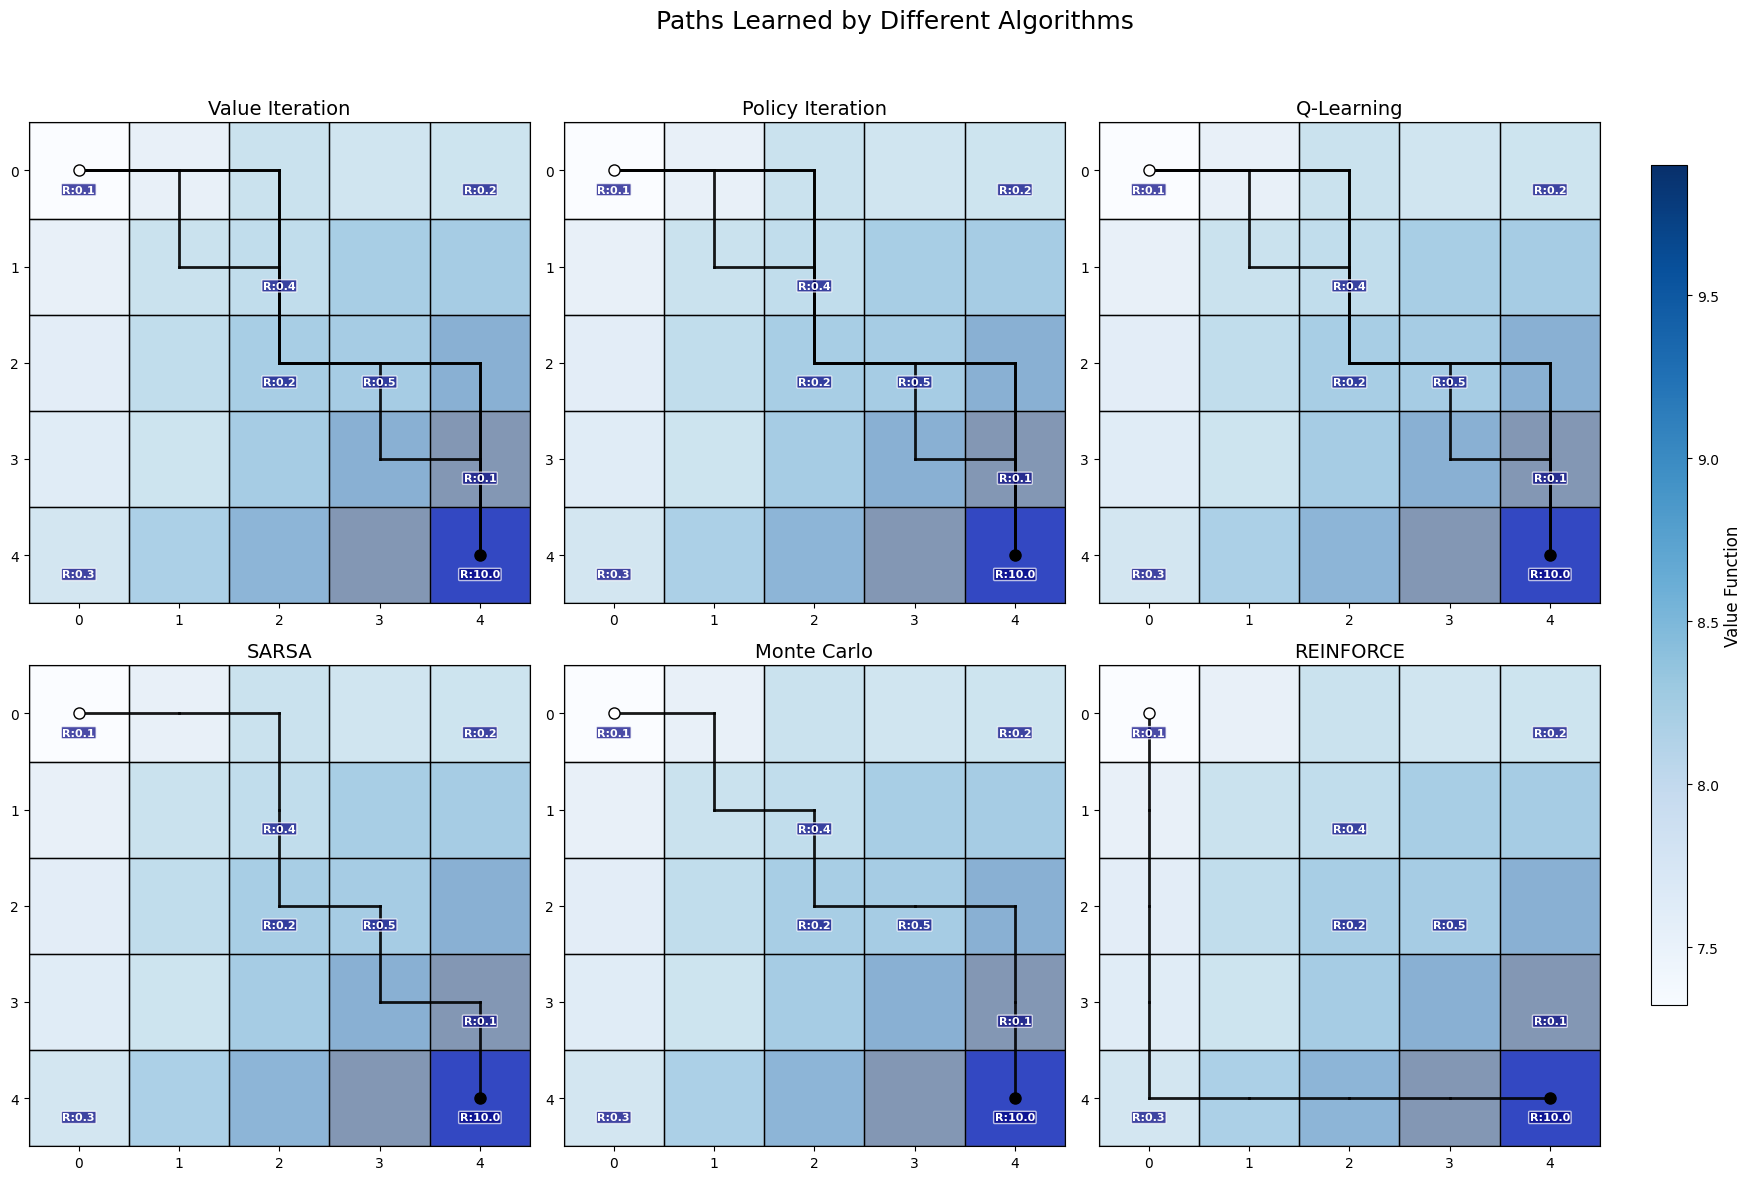

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

def plot_path(N, rewards, policy, start=(0, 0), max_steps=50, title=None):
    fig, ax = plt.subplots(figsize=(8, 8))
    
    for i in range(N+1):
        ax.axhline(i, color='black', lw=1)
        ax.axvline(i, color='black', lw=1)
    
    for (r, c), value in rewards.items():
        if value > 0:
            intensity = min(1.0, value / 10.0)
            color = (1, 1 - intensity, 0)
            ax.add_patch(Rectangle((c, N-r-1), 1, 1, color=color, alpha=0.5))
            ax.text(c+0.5, N-r-0.5, f"{value}", ha='center', va='center', fontsize=12)
    
    path = []
    s = start
    steps = 0
    done = False
    
    while not done and steps < max_steps and policy.get(s) is not None:
        path.append(s)
        a = policy[s]
        s, _, done = next_state_reward(s, a, N, rewards)
        steps += 1
        
        if done or is_terminal(s, N):
            path.append(s)
            break
    
    for i in range(len(path) - 1):
        r1, c1 = path[i]
        r2, c2 = path[i+1]
        ax.plot([c1+0.5, c2+0.5], [N-r1-0.5, N-r2-0.5], 'b-', lw=2)
        ax.plot(c1+0.5, N-r1-0.5, 'bo', markersize=8)
    
    ax.plot(start[1]+0.5, N-start[0]-0.5, 'go', markersize=10)
    if path:
        ax.plot(path[-1][1]+0.5, N-path[-1][0]-0.5, 'ro', markersize=10)
    
    ax.set_xlim(0, N)
    ax.set_ylim(0, N)
    ax.set_xticks(np.arange(0.5, N, 1))
    ax.set_yticks(np.arange(0.5, N, 1))
    ax.set_xticklabels(range(N))
    ax.set_yticklabels(range(N-1, -1, -1))
    if title:
        ax.set_title(title)
    else:
        ax.set_title('Path in Grid World')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_all_paths(N, rewards, policies, names, start=(0, 0), max_steps=50):
    fig, axes = plt.subplots(1, len(policies), figsize=(5*len(policies), 5))
    
    for i, (policy, name) in enumerate(zip(policies, names)):
        ax = axes[i]
        
        for j in range(N+1):
            ax.axhline(j, color='black', lw=1)
            ax.axvline(j, color='black', lw=1)
        
        for (r, c), value in rewards.items():
            if value > 0:
                intensity = min(1.0, value / 10.0)
                color = (1, 1 - intensity, 0)
                ax.add_patch(Rectangle((c, N-r-1), 1, 1, color=color, alpha=0.5))
                ax.text(c+0.5, N-r-0.5, f"{value}", ha='center', va='center', fontsize=10)
        
        path = []
        s = start
        steps = 0
        done = False
        
        while not done and steps < max_steps and policy.get(s) is not None:
            path.append(s)
            a = policy[s]
            s, _, done = next_state_reward(s, a, N, rewards)
            steps += 1
            
            if done or is_terminal(s, N):
                path.append(s)
                break
        
        for j in range(len(path) - 1):
            r1, c1 = path[j]
            r2, c2 = path[j+1]
            ax.plot([c1+0.5, c2+0.5], [N-r1-0.5, N-r2-0.5], 'b-', lw=2)
            ax.plot(c1+0.5, N-r1-0.5, 'bo', markersize=6)
        
        ax.plot(start[1]+0.5, N-start[0]-0.5, 'go', markersize=8, label='Start')
        if path:
            ax.plot(path[-1][1]+0.5, N-path[-1][0]-0.5, 'ro', markersize=8, label='End')
        
        ax.set_xlim(0, N)
        ax.set_ylim(0, N)
        ax.set_xticks(np.arange(0.5, N, 1))
        ax.set_yticks(np.arange(0.5, N, 1))
        ax.set_xticklabels(range(N))
        ax.set_yticklabels(range(N-1, -1, -1))
        ax.set_title(name)
        if i == 0:
            ax.legend(loc='upper left', bbox_to_anchor=(-0.1, -0.1))
    
    plt.tight_layout()
    plt.show()

def plot_path_grid(N, rewards, policies, policy_names, V_vi):
    rows = 2
    cols = 3
    fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
    axes = axes.flatten()
    
    # Create colormap for values - light to deep blue
    cmap = plt.cm.Blues
    all_values = [V_vi[s] for s in all_states(N) if not is_terminal(s, N)]
    vmin, vmax = min(all_values), max(all_values)
    norm = plt.Normalize(vmin, vmax)
    
    # Plot each algorithm's path
    for i, (policy, name) in enumerate(zip(policies, policy_names)):
        if i >= len(axes):
            break
            
        ax = axes[i]
        
        # Draw grid
        for j in range(N+1):
            ax.axhline(j, color='black', lw=1)
            ax.axvline(j, color='black', lw=1)
        
        # Color cells based on value function
        for r in range(N):
            for c in range(N):
                s = (r, c)
                # Cell color based on value
                if is_terminal(s, N):
                    color = (0.0, 0.1, 0.7)  # Deep blue
                    alpha = 0.8
                else:
                    color = cmap(norm(V_vi[s]))
                    alpha = 0.5
                
                ax.add_patch(Rectangle((c, N-r-1), 1, 1, facecolor=color, alpha=alpha, edgecolor='gray'))
        
        # Add reward markers
        for (r, c), value in rewards.items():
            if value > 0:
                ax.text(c+0.5, N-r-0.7, f"R:{value}", ha='center', va='center', 
                       fontsize=8, color='white', fontweight='bold',
                       bbox=dict(facecolor='navy', alpha=0.7, edgecolor='white', boxstyle='round,pad=0.1'))
        
        # Find and plot all possible paths (for policies with ties) in black
        def find_all_paths(start=(0, 0), max_depth=50):
            def dfs(current, path, all_paths):
                if is_terminal(current, N) or len(path) > max_depth:
                    all_paths.append(path.copy())
                    return
                
                if policy.get(current) is None:
                    all_paths.append(path.copy())
                    return
                
                actions = policy[current]
                if not isinstance(actions, list):
                    actions = [actions]
                
                for a in actions:
                    next_state, _, _ = next_state_reward(current, a, N, rewards)
                    if next_state not in path:  # Avoid cycles
                        path.append(next_state)
                        dfs(next_state, path, all_paths)
                        path.pop()
            
            paths = []
            dfs(start, [start], paths)
            return paths
        
        # Get all possible paths
        all_paths = find_all_paths()
        
        # Draw all paths in black
        for path in all_paths[:3]:  # Limit to 3 paths for clarity
            # Draw path
            for j in range(len(path) - 1):
                r1, c1 = path[j]
                r2, c2 = path[j+1]
                ax.plot([c1+0.5, c2+0.5], [N-r1-0.5, N-r2-0.5], 
                       color='black', lw=2, alpha=0.9, linestyle='-')
        
        # Mark start and goal
        ax.plot(0.5, N-0.5, 'wo', markersize=8, markeredgecolor='black')
        ax.plot(N-0.5, 0.5, 'ko', markersize=8)
        
        ax.set_xlim(0, N)
        ax.set_ylim(0, N)
        ax.set_xticks(np.arange(0.5, N, 1))
        ax.set_yticks(np.arange(0.5, N, 1))
        ax.set_xticklabels(range(N))
        ax.set_yticklabels(range(N-1, -1, -1))
        ax.set_title(name, fontsize=14)
    
    # Add colorbar to the figure
    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=cax)
    cbar.set_label('Value Function', fontsize=12)
    
    # Hide any unused subplots
    for i in range(len(policies), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Paths Learned by Different Algorithms', fontsize=18)
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.show()
    return fig

# Plot grid of paths
fig = plot_path_grid(
    N, 
    rewards,
    [policy_vi, policy_pi, policy_q, policy_sarsa, policy_mc, policy_reinforce],
    ['Value Iteration', 'Policy Iteration', 'Q-Learning', 'SARSA', 'Monte Carlo', 'REINFORCE'],
    V_vi
)

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
import os
from matplotlib.animation import PillowWriter
from tqdm import tqdm

# Create directory for saving GIFs
os.makedirs('gifs', exist_ok=True)

# Environment configuration
N = 5
ACTIONS = ['L', 'R', 'U', 'D', 'S']
ACTION_VECTORS = {'L': (0, -1), 'R': (0, 1), 'U': (-1, 0), 'D': (1, 0), 'S': (0, 0)}

# Common parameters
GAMMA = 0.95
THETA = 1e-6
PENALTY = -0.1

#----------------------------------------------------------------------------------
# Helper Functions
#----------------------------------------------------------------------------------

def all_states(N):
    """Return all possible states in the grid world"""
    return [(r, c) for r in range(N) for c in range(N)]

def is_terminal(s, N):
    """Check if state is terminal (goal)"""
    return s == (N-1, N-1)

def get_rewards(N):
    """Define reward structure for the grid world"""
    rewards = {}
    rewards[(N-1, N-1)] = 10.0
    rewards[(N-2, N-1)] = 0.1
    rewards[(N//2, N//2)] = 0.2
    rewards[(0, 0)] = 0.1
    rewards[(0, N-1)] = 0.2
    rewards[(N-1, 0)] = 0.3
    rewards[(N//2-1, N//2)] = 0.4
    rewards[(N//2, N//2+1)] = 0.5
    return rewards

def next_state_reward(s, a, N, rewards, penalty=PENALTY):
    """Compute next state and reward given current state and action"""
    r, c = s
    if is_terminal(s, N):
        return s, 0.0, True
    
    dr, dc = ACTION_VECTORS[a]
    nr, nc = r + dr, c + dc
    if nr < 0 or nr >= N or nc < 0 or nc >= N:
        nr, nc = r, c
    
    ns = (nr, nc)
    reward = penalty
    if ns in rewards:
        reward += rewards[ns]
    
    done = ns == (N-1, N-1)
    return ns, reward, done

#----------------------------------------------------------------------------------
# Algorithms with History
#----------------------------------------------------------------------------------

def value_iteration_with_history(N, rewards, gamma=GAMMA, theta=THETA, max_iterations=100, capture_every=5):
    """Value Iteration algorithm that captures intermediate states"""
    V = {s: 0.0 for s in all_states(N)}
    
    # For history
    V_history = []
    policy_history = []
    
    print("Running Value Iteration with history...")
    for iteration in tqdm(range(1, max_iterations+1)):
        delta = 0
        for s in all_states(N):
            if is_terminal(s, N): continue
            
            v = V[s]
            best_q = float('-inf')
            for a in ACTIONS:
                ns, r, done = next_state_reward(s, a, N, rewards)
                q_sa = r + (0 if done else gamma * V[ns])
                best_q = max(best_q, q_sa)
            
            delta = max(delta, abs(v - best_q))
            V[s] = best_q
        
        # Compute and store policy at this iteration
        if iteration % capture_every == 0 or delta < theta:
            curr_policy = {}
            for s in all_states(N):
                if is_terminal(s, N):
                    curr_policy[s] = None
                    continue
                
                action_values = {}
                for a in ACTIONS:
                    ns, r, done = next_state_reward(s, a, N, rewards)
                    q_sa = r + (0 if done else gamma * V[ns])
                    action_values[a] = q_sa
                
                max_value = max(action_values.values())
                epsilon = 1e-6
                optimal_actions = [a for a, v in action_values.items() if abs(v - max_value) < epsilon]
                curr_policy[s] = optimal_actions
            
            # Deep copy current state
            V_history.append({s: v for s, v in V.items()})
            policy_history.append({s: a.copy() if a else None for s, a in curr_policy.items()})
        
        if delta < theta:
            break
    
    # Ensure we have at least one frame in history
    if not V_history:
        V_history.append(V.copy())
        
        # Extract final policy
        final_policy = {}
        for s in all_states(N):
            if is_terminal(s, N):
                final_policy[s] = None
                continue
                
            action_values = {}
            for a in ACTIONS:
                ns, r, done = next_state_reward(s, a, N, rewards)
                q_sa = r + (0 if done else gamma * V[ns])
                action_values[a] = q_sa
                
            max_value = max(action_values.values())
            epsilon = 1e-6
            optimal_actions = [a for a, v in action_values.items() if abs(v - max_value) < epsilon]
            final_policy[s] = optimal_actions
            
        policy_history.append(final_policy)
    
    return V_history, policy_history

def q_learning_with_history(N, rewards, alpha=0.1, gamma=GAMMA, epsilon_start=1.0, episodes=2000, 
                           step_limit=50, capture_every=100):
    """Q-Learning algorithm that captures intermediate states"""
    Q = {s: {a: 0.0 for a in ACTIONS} for s in all_states(N)}
    
    # For history
    V_history = []
    policy_history = []
    
    print("Running Q-Learning with history...")
    for i in tqdm(range(episodes)):
        # Epsilon decay
        epsilon = epsilon_start * (1 - i/episodes)
        s = (0, 0)
        done = False
        steps = 0
        
        while not done and steps < step_limit:
            steps += 1
            
            # Epsilon-greedy policy
            if random.random() < epsilon:
                a = random.choice(ACTIONS)
            else:
                a = max(Q[s], key=Q[s].get)
            
            ns, r, done = next_state_reward(s, a, N, rewards)
            
            # Q-learning update
            Q[s][a] += alpha * (r + (0 if done else gamma * max(Q[ns].values())) - Q[s][a])
            
            s = ns
        
        # Capture history periodically
        if i % capture_every == 0 or i == episodes - 1:
            # Extract current value function and policy
            V = {}
            policy = {}
            for s in all_states(N):
                if is_terminal(s, N):
                    V[s] = 0.0
                    policy[s] = None
                    continue
                
                # Find all optimal actions
                max_q = max(Q[s].values())
                V[s] = max_q
                
                # Find all actions within epsilon of max value
                eps = 1e-6
                optimal_actions = [a for a, q in Q[s].items() if abs(q - max_q) < eps]
                policy[s] = optimal_actions
            
            # Store history
            V_history.append(V.copy())
            policy_history.append({s: a.copy() if a else None for s, a in policy.items()})
    
    return V_history, policy_history

#----------------------------------------------------------------------------------
# Simple Visualization Function
#----------------------------------------------------------------------------------

def create_grid_world_animation(V_history, policy_history, algo_name, output_file, fps=5):
    """Create an animation of the learning process"""
    fig, ax = plt.subplots(figsize=(8, 8))
    
    rewards = get_rewards(N)
    
    def animate(i):
        ax.clear()
        
        # Get the value function and policy for this frame
        V = V_history[i]
        policy = policy_history[i]
        
        # Draw grid
        for j in range(N+1):
            ax.axhline(j, color='black', lw=1)
            ax.axvline(j, color='black', lw=1)
        
        # Color cells based on value function
        vmin = min(V[s] for s in all_states(N) if not is_terminal(s, N))
        vmax = max(V[s] for s in all_states(N) if not is_terminal(s, N))
        
        for r in range(N):
            for c in range(N):
                s = (r, c)
                
                # Determine cell color based on value
                if is_terminal(s, N):
                    # Goal state
                    color = 'green'
                    alpha = 0.7
                else:
                    # Normalize value to [0, 1] range
                    if vmax > vmin:
                        normalized_value = (V[s] - vmin) / (vmax - vmin)
                    else:
                        normalized_value = 0.5
                    
                    # Use blue color with intensity based on value
                    color = (0.7*(1-normalized_value), 0.7*(1-normalized_value), 0.9)
                    alpha = 0.5
                
                # Draw cell
                ax.add_patch(Rectangle((c, N-r-1), 1, 1, facecolor=color, alpha=alpha, edgecolor='gray'))
                
                # Add value text
                ax.text(c+0.5, N-r-0.3, f"{V[s]:.2f}", ha='center', va='center', 
                       fontsize=8, color='black', fontweight='bold')
        
        # Draw policy arrows
        for r in range(N):
            for c in range(N):
                s = (r, c)
                if is_terminal(s, N) or policy[s] is None:
                    continue
                
                # Draw arrows for all optimal actions
                for a in policy[s]:
                    if a == 'L':
                        ax.arrow(c+0.6, N-r-0.5, -0.2, 0, head_width=0.15, head_length=0.08, fc='white', ec='white')
                    elif a == 'R':
                        ax.arrow(c+0.4, N-r-0.5, 0.2, 0, head_width=0.15, head_length=0.08, fc='white', ec='white')
                    elif a == 'U':
                        ax.arrow(c+0.5, N-r-0.6, 0, 0.2, head_width=0.15, head_length=0.08, fc='white', ec='white')
                    elif a == 'D':
                        ax.arrow(c+0.5, N-r-0.4, 0, -0.2, head_width=0.15, head_length=0.08, fc='white', ec='white')
                    elif a == 'S':
                        ax.add_patch(plt.Circle((c+0.5, N-r-0.5), 0.08, fc='white'))
        
        # Set title and axis limits
        percentage = int((i + 1) / len(V_history) * 100)
        ax.set_title(f"{algo_name} - Progress: {percentage}%", fontsize=14)
        ax.set_xlim(0, N)
        ax.set_ylim(0, N)
        ax.set_xticks(np.arange(0.5, N, 1))
        ax.set_yticks(np.arange(0.5, N, 1))
        ax.set_xticklabels(range(N))
        ax.set_yticklabels(range(N-1, -1, -1))
    
    # Create animation
    frames = len(V_history)
    anim = FuncAnimation(fig, animate, frames=frames, interval=1000/fps)
    
    # Save as GIF
    anim.save(output_file, writer=PillowWriter(fps=fps))
    plt.close(fig)
    
    print(f"Animation saved to {output_file}")

def create_comparison_animation(algorithms_data, output_file, fps=5):
    """Create a side-by-side comparison animation of multiple algorithms"""
    n_algos = len(algorithms_data)
    rows = (n_algos + 1) // 2
    cols = min(n_algos, 2)
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, 6*rows))
    if n_algos == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    # Normalize all animations to the same length
    max_frames = max(len(data["V_history"]) for data in algorithms_data)
    
    def animate(i):
        for ax in axes:
            ax.clear()
        
        for ax_idx, (ax, algo_data) in enumerate(zip(axes, algorithms_data)):
            if ax_idx >= n_algos:
                ax.axis('off')
                continue
            
            # Get frame index for this algorithm
            algo_frames = len(algo_data["V_history"])
            frame_idx = min(int(i * algo_frames / max_frames), algo_frames - 1)
            
            V = algo_data["V_history"][frame_idx]
            policy = algo_data["policy_history"][frame_idx]
            
            # Draw grid
            for j in range(N+1):
                ax.axhline(j, color='black', lw=1)
                ax.axvline(j, color='black', lw=1)
            
            # Calculate value range for color mapping
            vmin = min(V[s] for s in all_states(N) if not is_terminal(s, N))
            vmax = max(V[s] for s in all_states(N) if not is_terminal(s, N))
            
            for r in range(N):
                for c in range(N):
                    s = (r, c)
                    
                    # Determine cell color based on value
                    if is_terminal(s, N):
                        # Goal state
                        color = 'green'
                        alpha = 0.7
                    else:
                        # Normalize value to [0, 1] range
                        if vmax > vmin:
                            normalized_value = (V[s] - vmin) / (vmax - vmin)
                        else:
                            normalized_value = 0.5
                        
                        # Use blue color with intensity based on value
                        color = (0.7*(1-normalized_value), 0.7*(1-normalized_value), 0.9)
                        alpha = 0.5
                    
                    # Draw cell
                    ax.add_patch(Rectangle((c, N-r-1), 1, 1, facecolor=color, alpha=alpha, edgecolor='gray'))
                    
                    # Add value text (smaller for comparison view)
                    ax.text(c+0.5, N-r-0.3, f"{V[s]:.1f}", ha='center', va='center', 
                           fontsize=6, color='black', fontweight='bold')
            
            # Draw policy arrows (smaller for comparison view)
            for r in range(N):
                for c in range(N):
                    s = (r, c)
                    if is_terminal(s, N) or policy[s] is None:
                        continue
                    
                    # Draw arrows for all optimal actions
                    for a in policy[s]:
                        if a == 'L':
                            ax.arrow(c+0.6, N-r-0.5, -0.2, 0, head_width=0.1, head_length=0.05, fc='white', ec='white')
                        elif a == 'R':
                            ax.arrow(c+0.4, N-r-0.5, 0.2, 0, head_width=0.1, head_length=0.05, fc='white', ec='white')
                        elif a == 'U':
                            ax.arrow(c+0.5, N-r-0.6, 0, 0.2, head_width=0.1, head_length=0.05, fc='white', ec='white')
                        elif a == 'D':
                            ax.arrow(c+0.5, N-r-0.4, 0, -0.2, head_width=0.1, head_length=0.05, fc='white', ec='white')
                        elif a == 'S':
                            ax.add_patch(plt.Circle((c+0.5, N-r-0.5), 0.05, fc='white'))
            
            # Set title and axis limits
            percentage = int((i + 1) / max_frames * 100)
            ax.set_title(f"{algo_data['name']} - {percentage}%", fontsize=10)
            ax.set_xlim(0, N)
            ax.set_ylim(0, N)
            ax.set_xticks(np.arange(0.5, N, 1))
            ax.set_yticks(np.arange(0.5, N, 1))
            ax.set_xticklabels(range(N))
            ax.set_yticklabels(range(N-1, -1, -1))
        
        fig.suptitle("Reinforcement Learning Algorithms", fontsize=16)
        plt.tight_layout()
        plt.subplots_adjust(top=0.90)
    
    # Create animation
    anim = FuncAnimation(fig, animate, frames=max_frames, interval=1000/fps)
    
    # Save as GIF
    anim.save(output_file, writer=PillowWriter(fps=fps))
    plt.close(fig)
    
    print(f"Comparison animation saved to {output_file}")

#----------------------------------------------------------------------------------
# Main Function
#----------------------------------------------------------------------------------

def main():
    random.seed(42)
    np.random.seed(42)
    rewards = get_rewards(N)
    
    # Run Value Iteration and create animation
    V_history_vi, policy_history_vi = value_iteration_with_history(
        N, rewards, capture_every=1, max_iterations=15
    )
    create_grid_world_animation(
        V_history_vi, policy_history_vi, 
        "Value Iteration", "gifs/value_iteration.gif"
    )
    
    # Run Q-Learning and create animation
    V_history_q, policy_history_q = q_learning_with_history(
        N, rewards, capture_every=10, episodes=1000
    )
    create_grid_world_animation(
        V_history_q, policy_history_q, 
        "Q-Learning", "gifs/q_learning.gif"
    )
    
    # Create comparison animation
    algorithms_data = [
        {"name": "Value Iteration", "V_history": V_history_vi, "policy_history": policy_history_vi},
        {"name": "Q-Learning", "V_history": V_history_q, "policy_history": policy_history_q}
    ]
    create_comparison_animation(algorithms_data, "gifs/comparison.gif")
    
    print("All animations created successfully!")

if __name__ == "__main__":
    main()

Running Value Iteration with history...


 53%|█████▎    | 8/15 [00:00<00:00, 6109.69it/s]


Animation saved to gifs/value_iteration.gif
Running Q-Learning with history...


100%|██████████| 1000/1000 [00:00<00:00, 53217.75it/s]


Animation saved to gifs/q_learning.gif
Comparison animation saved to gifs/comparison.gif
All animations created successfully!
